In [1]:
from matplotlib import pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from sklearn import model_selection, metrics

from mics import qrisk3, simulation

In [2]:
# start small for a fast iteration, the scale up to 100k patients once the pipeline runs cleanly
n_patients = 1000 
random_seed = 42

In [3]:
# Generate population
patients = simulation.generate_patients(n_patients, random_seed=random_seed)
display(patients)

Age,Sex,Ethnicity,Townsend_Score,BMI,Systolic_Blood_Pressure,SD_Systolic_Blood_Pressure,Cholesterol_HDL_Ratio,Smoking Status,Type 1 Diabetes,Type 2 Diabetes,SLE,Severe Mental Illness,CKD,Atrial_Fibrillation,Rheumatoid_Arthritis,Migraine,Erectile_Disfunction,Corticosteroids,Atypical_Antipsychotics,Treated Hypertension,Family History of CVD
i64,str,str,f64,f64,f64,f64,f64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
71,"""Male""","""White""",-3.46013,31.17,137.5,2.06,2.93,"""Moderate Smoker""",0,0,0,0,0,0,0,1,1,0,0,0,1
34,"""Female""","""White""",-3.9634,26.09,127.98,5.27,3.08,"""Non-Smoker""",0,0,0,0,0,0,0,1,0,0,0,0,0
80,"""Male""","""White""",-0.626348,24.88,128.2,1.51,6.34,"""Ex Smoker""",0,0,0,0,1,0,0,0,0,0,0,0,1
40,"""Male""","""White""",4.752243,25.69,113.8,2.67,4.71,"""Non-Smoker""",0,0,0,0,0,0,0,0,0,0,0,0,0
43,"""Male""","""White""",-2.289765,29.55,129.12,2.16,1.5,"""Non-Smoker""",0,0,0,0,0,0,0,0,1,0,0,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
73,"""Female""","""White""",2.142096,30.01,146.82,4.77,3.01,"""Non-Smoker""",0,0,0,0,0,0,0,1,0,0,0,0,0
84,"""Female""","""White""",6.410805,27.41,129.52,4.76,4.32,"""Non-Smoker""",0,0,0,0,0,0,0,1,0,0,0,1,0
70,"""Male""","""White""",-1.597388,33.27,142.15,3.57,5.12,"""Non-Smoker""",0,0,0,0,0,1,0,0,1,0,0,0,0


# 

In [4]:
# Prevelance of Type 2 diabetes in patients over 60 should be ~ 12%, rising with BMI 
patients.filter(
    pl.col("Age") > 60
)['Type 2 Diabetes'].value_counts(sort=True, normalize=True)

Type 2 Diabetes,proportion
i64,f64
0,0.879452
1,0.120548


In [5]:
# Type 2 diabetes prevalence should rise with age, and be higher in patients with higher BMI 
# Simple plot demonstrates this relationship - future step is to confrim via anaysis of the data
patients.group_by("Age").agg(
    (pl.col("Type 2 Diabetes")==1).mean().alias("Type 2 Diabetes")
).sort("Age").plot.line(x="Age", y="Type 2 Diabetes")

alt.Chart(...)

# Generate the 10 year risk for our patients

Population Statistics: shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 1000.0    │
│ null_count ┆ 0.0       │
│ mean       ┆ 12.183431 │
│ std        ┆ 13.824535 │
│ min        ┆ 0.016665  │
│ 25%        ┆ 1.341797  │
│ 50%        ┆ 6.480005  │
│ 75%        ┆ 19.156131 │
│ max        ┆ 82.483283 │
└────────────┴───────────┘
Patients risk as percentages (0-100): [2.83348232e+01 4.51922343e-01 4.76714504e+01 1.59867808e+00
 2.83227379e+00 4.76866761e-02 4.53910582e+00 1.74975853e+01
 9.56080536e-02 4.31051491e+00 1.35188272e+01 2.36022640e-02
 5.68394402e+01 2.93349266e+01 6.17473496e-01 6.24971809e+00
 8.24832832e+01 2.95278749e+00 3.88715754e+01 3.00877647e+01
 1.06835050e+01 3.32253484e+01 1.06108839e+00 3.22273891e+01
 2.53514940e+01 1.29845487e+01 3.45180137e+01 1.42903090e+01
 4.55064597e+01 4.16323133e+01 5.29812285e-02 2.14390615e+01
 8.89864081e-01 1.55577425e+00 1

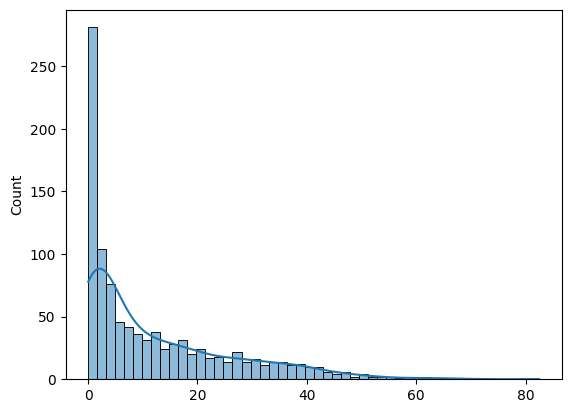

In [6]:
# This is the first step to generating the 'y' variable in our formulation. 
# Now, we have X (a matrix of risk factors), and each patient's 10 year CVD risk using QRISK3
# This returns a percentage between 0 and 100 - the the probability of a patient having a CVD event in the next 10 years

# Need to confirm that the distribution of risk looks reasonable, 
# and that the relationship between risk and 'y' (CVD event) is as expected 
patient_risk = qrisk3.calculate_qrisk3(patients)

# Perform a sanity check before plotting and generating y 
print("Population Statistics:", patient_risk.describe())
 
# Convert risk scores to numpy array for plotting, outcome sampling and further analysis
risk_pct = patient_risk.to_numpy()

# Plot distribution of risk - should be right skewed 
#TODO: need to fix the x-axis to be between 0 and 100, and add a vertical line at the mean risk
sns.histplot(risk_pct, bins=50, kde=True)

# Display risk as percentages (0-100)
print("Patients risk as percentages (0-100):", risk_pct)

# Simulate the outcomes

In [7]:
# Bernoulli sampling: 'y' is 1 if a CVD event occurs, otherwise 0 - binary outcome.
# To be used as the training target for model 1. Can the model learn the relationship between 'X' (risk factors), 
# and risk 'y' and therefore learn to predict 'y' from 'X'?

y = simulation.risk_to_event(risk_pct, random_seed=random_seed)

risk_prob = risk_pct / 100 # Recomputed for inspection

# Sanity check: 
# The event rate should be close to the mean calculated risk by QRISK3 
# The mean(y) should be close to the mean(risk_prob) - it checks that the Bernoulli sampling produces the correct ouput
print("Patients risk as predicted probabilities (0-1):", risk_prob[:10])
print("Simulated CVD events (y):", y[:10])

# Show comparisons 
print("Mean risk (%):", risk_pct.mean())
print("Event rate (%):", y.mean() * 100)
print("Event count:", y.sum())


Patients risk as predicted probabilities (0-1): [0.28334823 0.00451922 0.4767145  0.01598678 0.02832274 0.00047687
 0.04539106 0.17497585 0.00095608 0.04310515]
Simulated CVD events (y): [0 0 0 0 0 0 0 0 0 0]
Mean risk (%): 12.183431328551368
Event rate (%): 12.8
Event count: 128


In [8]:
# Test the function on a larger sample of patients - n = 10,000

# Sanity check: 
# When scaled the function should give the same event rate as the mean risk percentage from QRISK3.
# The random variation averages out and mean(y) should be very closly matched to mean(risk_prob.
# This connfirms the Bernoulli sompling is producing the correct distribution at scale. 

# Generate larger population and convert into numpy array for analysis
large_patients = simulation.generate_patients(n=10000, random_seed=42)
large_risk_pct= qrisk3.calculate_qrisk3(large_patients).to_numpy()

# Simulate outcomes 
y_large = simulation.risk_to_event(large_risk_pct, random_seed=random_seed)

# Show comparisons
print("Mean risk (%):", large_risk_pct.mean())
print("Event rate (%):", y_large.mean() * 100)
print("Event count:", y_large.sum())

Mean risk (%): 12.077980871939863
Event rate (%): 12.24
Event count: 1224


# Build the feature matrix 

In [9]:
# Make a copy of the patients dataframe to avoid modifications to the original
matrix = patients.clone()

# One-hot encode the categorical variables 
# It turns each category into its own separate binary column (0/1)
matrix = matrix.to_dummies(columns=["Sex", "Ethnicity", "Smoking Status"])

# Convert into numpy array for model fitting
X = matrix.to_numpy()

# Sanity check:
# The shape of X should be (n_patients, n_features) - n_features is the number of risk factors after one-hot encoding
print("Column names:", matrix.columns)
print("Shape of X:", X.shape)
print("First row of X:", X[0])


Column names: ['Age', 'Sex_Female', 'Sex_Male', 'Ethnicity_Bangladeshi', 'Ethnicity_Black African', 'Ethnicity_Black Caribbean', 'Ethnicity_Chinese', 'Ethnicity_Indian', 'Ethnicity_Other Asian', 'Ethnicity_Other Ethnic Group', 'Ethnicity_Pakistani', 'Ethnicity_White', 'Townsend_Score', 'BMI', 'Systolic_Blood_Pressure', 'SD_Systolic_Blood_Pressure', 'Cholesterol_HDL_Ratio', 'Smoking Status_Ex Smoker', 'Smoking Status_Heavy Smoker', 'Smoking Status_Light Smoker', 'Smoking Status_Moderate Smoker', 'Smoking Status_Non-Smoker', 'Type 1 Diabetes', 'Type 2 Diabetes', 'SLE', 'Severe Mental Illness', 'CKD', 'Atrial_Fibrillation', 'Rheumatoid_Arthritis', 'Migraine', 'Erectile_Disfunction', 'Corticosteroids', 'Atypical_Antipsychotics', 'Treated Hypertension', 'Family History of CVD']
Shape of X: (1000, 35)
First row of X: [ 71.           0.           1.           0.           0.
   0.           0.           0.           0.           0.
   0.           1.          -3.46012957  31.17       137.5
  

# Fit a model to predict the risk

We want $y'=f(X)$ to estimate y

TODO: We don't have a test dataset here. We've used the whole `X` and `y` data to fit the model, so we can't evaluate how well it performs on unseen data. We should split our data into a training set and a test set to properly evaluate the model's performance.

In [10]:
# Call fit_model function

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=random_seed)

model_1 = simulation.fit_model(X_train,y_train)

# Sanity check:
# The predicted event rate should be close to the actual event rate in 'y'; this ensures the model is well calibrated

print("Actual event rate:", y_test.mean())
M_1 = model_1.predict_proba(X_test)[:,1]
print("Model 1 average predicted event rate:", M_1.mean())
# The predicted probabilities of a CVD event outcome for each patient
# It gives a two column array: the probability of the patient belonging to class 0 (no event) and class 1 (event). 
# We only care about the probability of an event - the second column; index 1.


#TODO: Inspect model coefficients to confirm that the model has learned the expected relationships between risk factors and CVD events.
# Does it make biological sense? 
# E.g. Are aga and AF positively associated with CVD risk? Is sex_female negatively associated with CVD risk? 
# Are the relationships in line with existing medical knowledge and literature on CVD risk factors?



Actual event rate: 0.13
Model 1 average predicted event rate: 0.13203857240695044


## Analyse how good the model is at predicting the risk

### Confusion Matrix - but you need to choose a threshold

This is a bit arbitrary, and it doesn't capture the full picture of the model's performance across all possible thresholds.

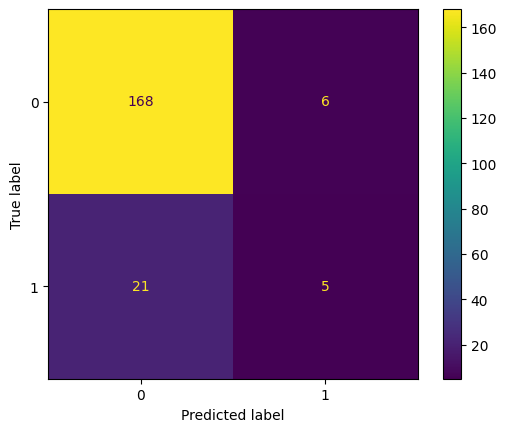

In [11]:
y_pred_prob = model_1.predict_proba(X_test)[:,1]
threshold = 0.5
metrics.ConfusionMatrixDisplay(
    metrics.confusion_matrix(
        y_true = y_test,
        y_pred = (y_pred_prob > threshold).astype(int)
    )
).plot()


### AUC 

This compares performance across all possible thresholds, and is a good overall measure of how well the model can discriminate between patients who will have an event and those who won't.

AUC-ROC: 0.7953138815207781


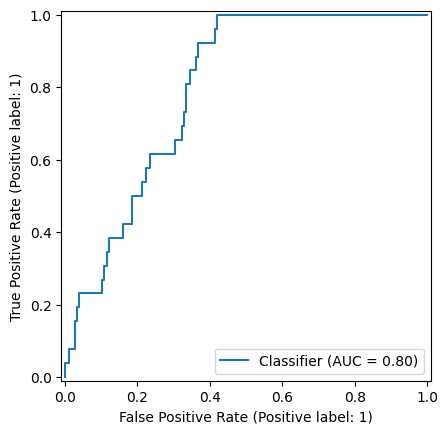

In [12]:
metrics.RocCurveDisplay.from_predictions(y_test, y_pred_prob)
print("AUC-ROC:", metrics.roc_auc_score(y_test, y_pred_prob))

Violinplot shows the difference in the _scores_ between patients who had an event and those who didn't die. We expect to see higher predicted probabilities for patients who had an event (y=1) compared to those who didn't (y=0). If the model is performing well, the distribution of predicted probabilities for y=1 should be skewed towards higher values, while the distribution for y=0 should be skewed towards lower values.

(0.0, 1.0)

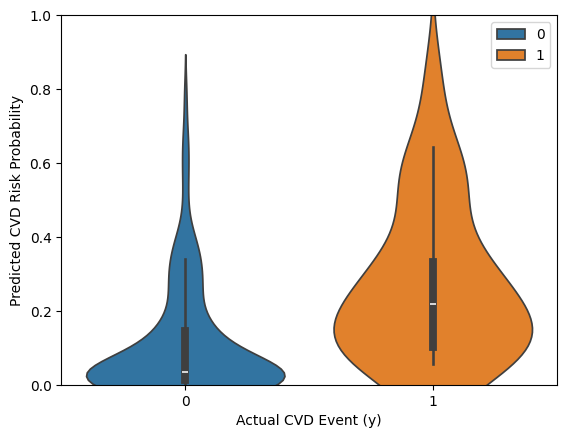

In [13]:
sns.violinplot(x=y_test, y=y_pred_prob, hue=y_test)
plt.xlabel("Actual CVD Event (y)")
plt.ylabel("Predicted CVD Risk Probability")
plt.ylim(0,1)

Conclusion: Model 1 is OK, possibly could be a bit better. 

Improvements might involve:
* Using a bigger dataset. 
* Using a more complex model (e.g. random forest, gradient boosting, neural network).

# Implement the model a new population

In [14]:
# Generate a new population. Use a different random seed so we don't get the exact same patients. 
patients_2 = simulation.generate_patients(n_patients, random_seed=random_seed + 1)
#display(patients_2)

# Build a new feature matrix for the new population, and calculate their QRISK3 risk scores.
matrix_2 = patients_2.clone()
matrix_2 = matrix_2.to_dummies(columns=["Sex", "Ethnicity", "Smoking Status"])
X_2 = matrix_2.to_numpy()

# Sanity check: 
#print(" Shape of X_2:", X_2.shape)

# Deploy model 1 (M1) to predict the risk of CVD events in this new population.
predicted_risk_b = model_1.predict_proba(X_2)[:,1]
print("Model 1 average predicted event rate in new population:", predicted_risk_b.mean())
print("First 10 predicted probabilities of CVD events:", predicted_risk_b[:10])


Model 1 average predicted event rate in new population: 0.12740133766125494
First 10 predicted probabilities of CVD events: [0.26908527 0.16436703 0.01755738 0.14170636 0.01543636 0.28588242
 0.02450753 0.5103469  0.03832193 0.65951315]


## Identify patients who will recieve the statin intervention 

In [15]:
# NICE CG181 threshold: CVD predicted risk >= 10% triggers GP statin prescribing.
# M1 predicted_risk is on the 0-1 scale, so the threshold is 0.10
on_statins = predicted_risk_b >= 0.10

# Add the on_statin column to the patients_2 dataframe to indicate patient status
# Creating a new series with the same length as patients_2, where each value is True if the patient is on statins and False otherwise.
patients_2 = patients_2.with_columns(pl.Series("on_statins", on_statins))
display(patients_2)

# Sanity check:
# No. of patients who are eligible for statin prescribing based on predicted risk? What fraction of the population is this?
print("Number of patients eligible for statin prescribing:", on_statins.sum())
print(f"Fraction of population eligible for statin prescribing: {on_statins.mean():.1%}")

Age,Sex,Ethnicity,Townsend_Score,BMI,Systolic_Blood_Pressure,SD_Systolic_Blood_Pressure,Cholesterol_HDL_Ratio,Smoking Status,Type 1 Diabetes,Type 2 Diabetes,SLE,Severe Mental Illness,CKD,Atrial_Fibrillation,Rheumatoid_Arthritis,Migraine,Erectile_Disfunction,Corticosteroids,Atypical_Antipsychotics,Treated Hypertension,Family History of CVD,on_statins
i64,str,str,f64,f64,f64,f64,f64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,bool
84,"""Female""","""White""",-3.28173,28.58,131.67,2.21,3.52,"""Non-Smoker""",0,1,0,0,0,0,1,0,0,0,0,0,0,true
69,"""Male""","""White""",-2.308918,27.05,130.42,4.88,4.26,"""Non-Smoker""",0,1,0,0,0,0,0,1,0,0,0,0,0,true
41,"""Female""","""White""",5.824413,30.57,149.65,5.15,2.72,"""Heavy Smoker""",1,0,0,0,0,0,0,0,0,0,0,0,1,false
78,"""Female""","""Other Ethnic Group""",2.819072,31.37,140.25,1.24,4.42,"""Non-Smoker""",0,0,0,0,1,0,0,1,0,0,0,0,0,true
36,"""Female""","""White""",0.662549,30.66,115.86,3.64,5.61,"""Light Smoker""",0,1,0,0,0,0,0,1,0,0,0,0,1,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
68,"""Female""","""White""",3.727827,25.3,152.18,1.29,4.92,"""Ex Smoker""",0,0,0,0,0,0,0,0,0,0,0,0,1,true
25,"""Female""","""White""",0.935357,19.66,124.19,1.85,4.64,"""Non-Smoker""",0,0,0,1,0,0,0,0,0,0,0,0,1,false
65,"""Male""","""Pakistani""",-4.256871,25.69,136.0,3.85,4.22,"""Ex Smoker""",0,0,0,0,0,0,0,1,0,0,0,0,0,true


Number of patients eligible for statin prescribing: 381
Fraction of population eligible for statin prescribing: 38.1%


## Generate the true QRISK3 risk for the second population

In [16]:
# Calculate the true underlying risk for the new population using QRISK3.
# This is the ground truth risk; the underlying biological risk for each patient
# It can be used to evaluate how well M1 performed in this new population.
true_risk_b = qrisk3.calculate_qrisk3(patients_2).to_numpy()

# Sanity check:
# The mean true risk should be close to M1's mean predicted risk
print("Mean risk (%):", true_risk_b.mean())
print("Mean predicted risk (%):", predicted_risk_b.mean() * 100)


Mean risk (%): 11.948607965122527
Mean predicted risk (%): 12.740133766125494


## Apply the statin effect 

In [17]:
# Statins have a CVD relative risk reduction (RRR) of approximately 25%.
# They biologically lower true probability of a CVD event in patients who are prescribed them.

# Modify the true risk for treated patients only.
true_risk_post_b = true_risk_b.copy()

# Apply the 25% relative risk reduction.
# Untreated patients remain unchanged.
true_risk_post_b[on_statins] = true_risk_post_b[on_statins] * (0.75)

# Sanity check:
# Compare the mean true risk before and after statin intervention. 
Checks_statin = [
    ("All patients (before intervention)", true_risk_b.mean()),
    ("All patients (after intervention)", true_risk_post_b.mean()),
    ("Untreated patients", true_risk_b[~on_statins].mean()),
    ("Treated patients (before statins)", true_risk_b[on_statins].mean()),
    ("Treated patients (after statins)", true_risk_post_b[on_statins].mean()),
]

for label, value in Checks_statin:
    print(f"{label}: {value:.2f}%")


All patients (before intervention): 11.95%
All patients (after intervention): 9.59%
Untreated patients: 4.06%
Treated patients (before statins): 24.77%
Treated patients (after statins): 18.58%


## Generate post-intervention outcomes

In [18]:
# Bernoulli sampling from the true risk after statin intervention; treated patients have a lower probability of a CVD event than untreated patients.
# Their event rate should be lower than the untreated patients, and the overall event rate in the population should be lower than before statin intervention. 
# The binary outcome 'y_2' becomes the new target variable for model 2 (M2) 

# Simulate the ouctomes
y_2 = simulation.risk_to_event(true_risk_post_b, random_seed=random_seed + 1)

# Sanity check:
# Total events and overall event rate 
# Event rate for the treated vs untreated patients
Checks_outcome = [
    ("Total events", y_2.sum()),
    ("Overall event rate (%)", y_2.mean() * 100),
    ("Event rate for treated patients (%)", y_2[on_statins].mean() * 100),
    ("Event rate for untreated patients (%)", y_2[~on_statins].mean() * 100),
]
for check, value in Checks_outcome:
    print(f"{check}: {value:.2f}")

Total events: 83.00
Overall event rate (%): 8.30
Event rate for treated patients (%): 14.70
Event rate for untreated patients (%): 4.36


# Now we train a second model on our second population. 

Problem: training a model $f_2(x)$ but not accounting for statins.
This is the model-induced concept shift problem. 

In [20]:
# M2: the model that will be trained to predict CVD events in a new population, after the indtroduction of a statin intervention.
# MAKE SURE THAT MODEL 2 DOESN'T USE THE 'on_statins' COLUMN - IT SHOULDN'T BE A RISK FACTOR IN THE MODEL, IT'S AN INTERVENTION
# We can add this later, but as a first pass, we want the model to be unaware of the intervention, 
# and just see how the coefficients change after the intervention.

patients_2 = patients_2.drop("on_statins")

# This creates the MICS signal: M2 sees the attenutaed risk associations, 
# because the intervention has weakened the relationship between high-weight risk features and observed events
model_2 = simulation.fit_model(X_2, y_2)

# Sanity check:
print("Actual event rate in Population B:", y_2.mean())
print("Model 2 average predicted event rate:", model_2.predict_proba(X_2)[:, 1].mean())


Actual event rate in Population B: 0.083
Model 2 average predicted event rate: 0.08298484061154283


## Compare M1 and M2 coefficients - first instance of MICS

In [26]:
# Compre the coefficients of model 1 and model 2 to see how they differ after the simulated intervention (statin prescription).
# Is there signs of coeffecient attenuation for the high-weight risk factors
# Are M2's coefficents smaller in magnitude than M1's - sign of MICS occuring (possible weaker risk-factor relationships due to the intervention)

# If MICS is occurring, M2's coefficients on the strong risk factors (AF, T1D, SLE, smoking, age)
# should be smaller in magnitude than M1's. The intervention has reduced events for high-risk
# patients, so M2 sees a weaker apparent relationship between those features and outcomes.

high_risk_features = [
    "Age",
    "Atrial_Fibrillation",
    "Type 1 Diabetes",
    "Type 2 Diabetes",
    "SLE",
    "CKD",
    "Smoking Status_Heavy Smoker",
    "Family History of CVD",
]

# Build a small comparison table
coefficient_comparison = []
for feature in high_risk_features:
    i = matrix.columns.index(feature)
    coefficient_comparison.append({
        "Feature": feature,
        "M1 coefficient": model_1.coef_[0][i],
        "M2 coefficient": model_2.coef_[0][i],
        "Difference (M2 - M1)": model_2.coef_[0][i] - model_1.coef_[0][i],
    })

pl.DataFrame(coefficient_comparison)

Feature,M1 coefficient,M2 coefficient,Difference (M2 - M1)
str,f64,f64,f64
"""Age""",0.084355,0.054658,-0.029696
"""Atrial_Fibrillation""",0.365411,-0.193314,-0.558726
"""Type 1 Diabetes""",0.273365,2.150184,1.876819
"""Type 2 Diabetes""",-0.121615,0.344194,0.465809
"""SLE""",-0.006762,-0.158638,-0.151876
"""CKD""",-0.158046,-0.476296,-0.318251
"""Smoking Status_Heavy Smoker""",-0.465385,-0.56684,-0.101455
"""Family History of CVD""",0.223919,0.412526,0.188607


# Generated comparative third population 

In [22]:
# M2 should underpredict risk compared to M1 and the true event rate